# SMC Indicator Tester (Smart Money Concepts)

Test **Smart Money Concepts** indicators one cell at a time.

Includes: swing points, BOS, CHoCH, FVG, order blocks, liquidity sweeps, premium/discount.

```bash
pip install -e ".[notebook]"
jupyter lab notebooks/smc_indicator_tester.ipynb
```

1. Run setup cells once
2. Jump to any SMC block (Ctrl+F e.g. `FVG`, `BOS`)
3. Run only that cell


In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from indicator_testing.data_loader import describe_ohlc, load_ohlc
from indicator_testing.smc_indicators import SmcIndicatorRegistry
from indicator_testing.smc_runner import run_smc_indicator

print(f"Project root: {PROJECT_ROOT}")


Project root: d:\Projects\Indicator Testing


## Configuration


In [2]:
CSV_PATH = PROJECT_ROOT / "questdb-query-1781940224994.csv"
RESAMPLE = "daily"   # SMC works well on daily+; try "none" for 1-min
SYMBOL = None
SWING_LENGTH = 2     # bars each side for swing detection


In [3]:
resample_arg = None if RESAMPLE == "none" else RESAMPLE
df = load_ohlc(CSV_PATH, resample=resample_arg, symbol=SYMBOL, warn_short=False)
registry = SmcIndicatorRegistry()
info = describe_ohlc(df)

print(f"Loaded {info['bars']} bars | {info['inferred_frequency']}")
print(f"SMC indicators: {len(registry.all_names())}")
df.tail(3)


Loaded 52 bars | daily
SMC indicators: 17


C:\Users\mohxm\AppData\Local\Temp\ipykernel_9544\3697508958.py:2: UserWarning: Dropping 16500 duplicate timestamp(s), keeping last occurrence.
  df = load_ohlc(CSV_PATH, resample=resample_arg, symbol=SYMBOL, warn_short=False)


,open,high,low,close,volume
date,,,,,
2026-06-17 00:00:00+00:00,24044.5,24108.20,23969.70,24081.95,350689158
2026-06-18 00:00:00+00:00,24073.8,24189.25,24036.95,24179.40,337400862
2026-06-19 00:00:00+00:00,23991.2,24047.20,23901.90,24042.70,442811653


## Helpers


In [4]:
def show_validation(result):
    meta = registry.get(result.name)
    print(f"{'='*60}")
    print(f"{result.name}  |  {result.group}  (SMC)")
    print(f"Status: {result.status}  |  Warmup: {result.warmup_bars}")
    print(f"Outputs: {meta.output_names}  |  Params: {result.params_used}")
    if result.message and result.status != "success":
        print(f"Message: {result.message}")
    if result.validation:
        tag = "PASS" if result.validation.passed else "FAIL"
        print(f"Validation: {tag}")
        for c in result.validation.checks:
            mark = "OK" if c.passed else "X"
            print(f"  [{mark}] {c.name}: {c.message}")
    print(f"{'='*60}")


def result_to_frame(result, n_tail=20):
    if result.status != "success" or not result.outputs:
        return pd.DataFrame()
    out = pd.DataFrame({"close": df["close"]})
    for k, arr in result.outputs.items():
        out[k] = arr
    out.index = df.index
    # show rows with any signal
    numeric = out.select_dtypes(include="number")
    if len(numeric.columns):
        hits = numeric[(numeric != 0).any(axis=1) | numeric.notna().all(axis=1)]
        if len(hits):
            return hits.tail(n_tail)
    return out.tail(n_tail)


def plot_smc(result):
    if result.status != "success" or not result.outputs:
        print("Nothing to plot.")
        return
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df.index, df["close"], color="black", lw=1, label="Close")
    for key, arr in result.outputs.items():
        if arr.dtype == object:
            continue
        mask = pd.Series(arr, index=df.index).fillna(0) != 0
        if mask.any():
            ax.scatter(df.index[mask], df["close"][mask], s=30, label=key)
        elif "top" in key or "bottom" in key or "high" in key or "low" in key or key in {"equilibrium", "range_high", "range_low"}:
            ax.plot(df.index, arr, lw=0.8, alpha=0.7, label=key)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_title(f"{result.name} (SMC)")
    fig.tight_layout()
    plt.show()


def test_smc_indicator(name, params=None):
    p = dict(params or {})
    if "length" not in p and name not in {"FVG", "FVG_BULL", "FVG_BEAR"}:
        p.setdefault("length", SWING_LENGTH)
    result = run_smc_indicator(name, df, registry, params=p)
    show_validation(result)
    display(result_to_frame(result))
    plot_smc(result)
    return result


## Table of contents

- [Market Structure](#market-structure)
- [Fair Value Gaps](#fair-value-gaps)
- [Order Blocks](#order-blocks)
- [Liquidity](#liquidity)
- [Premium / Discount](#premium--discount)


<a id="market-structure"></a>
## Market Structure (7)


### SWING_HIGH
Outputs: `['swing_high', 'is_swing_high']` · Defaults: `{'length': 2}`


SWING_HIGH  |  Market Structure  (SMC)
Status: success  |  Warmup: 12
Outputs: ['swing_high', 'is_swing_high']  |  Params: {'length': 2}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,swing_high,is_swing_high
date,,,
2026-05-22 00:00:00+00:00,23748.85,NaN,0.0
2026-05-25 00:00:00+00:00,24049.90,NaN,0.0
2026-05-26 00:00:00+00:00,23933.75,24089.80,1.0
2026-05-27 00:00:00+00:00,23921.60,NaN,0.0
2026-05-29 00:00:00+00:00,23609.30,NaN,0.0
2026-06-01 00:00:00+00:00,23379.20,NaN,0.0
2026-06-02 00:00:00+00:00,23523.30,NaN,0.0
2026-06-03 00:00:00+00:00,23396.95,NaN,0.0
2026-06-04 00:00:00+00:00,23438.00,NaN,0.0


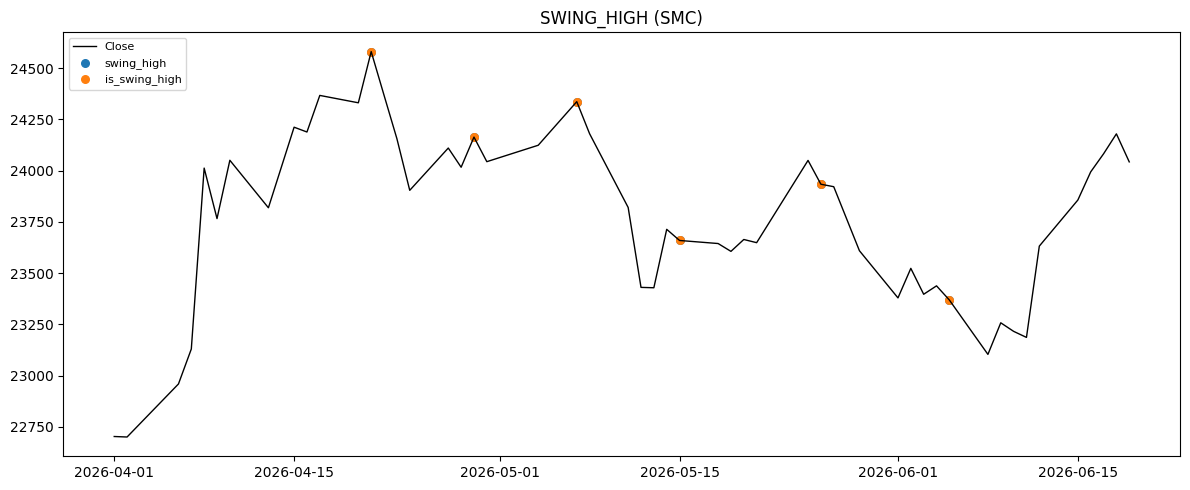

IndicatorResult(name='SWING_HIGH', group='Market Structure', params_used={'length': 2}, outputs={'swing_high': array([     nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
       24601.7 ,      nan,      nan,      nan,      nan,      nan,
       24334.7 ,      nan,      nan, 24482.1 ,      nan,      nan,
            nan,      nan,      nan, 23839.3 ,      nan,      nan,
            nan,      nan,      nan,      nan, 24089.8 ,      nan,
            nan,      nan,      nan,      nan,      nan, 23516.35,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan]), 'is_swing_high': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])}, warmup_bars=12, status='success', message='OK', 

In [5]:
test_smc_indicator("SWING_HIGH")


### SWING_LOW
Outputs: `['swing_low', 'is_swing_low']` · Defaults: `{'length': 2}`


SWING_LOW  |  Market Structure  (SMC)
Status: success  |  Warmup: 7
Outputs: ['swing_low', 'is_swing_low']  |  Params: {'length': 2}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,swing_low,is_swing_low
date,,,
2026-05-22 00:00:00+00:00,23748.85,NaN,0.0
2026-05-25 00:00:00+00:00,24049.90,NaN,0.0
2026-05-26 00:00:00+00:00,23933.75,NaN,0.0
2026-05-27 00:00:00+00:00,23921.60,NaN,0.0
2026-05-29 00:00:00+00:00,23609.30,NaN,0.0
2026-06-01 00:00:00+00:00,23379.20,NaN,0.0
2026-06-02 00:00:00+00:00,23523.30,NaN,0.0
2026-06-03 00:00:00+00:00,23396.95,23151.50,1.0
2026-06-04 00:00:00+00:00,23438.00,NaN,0.0


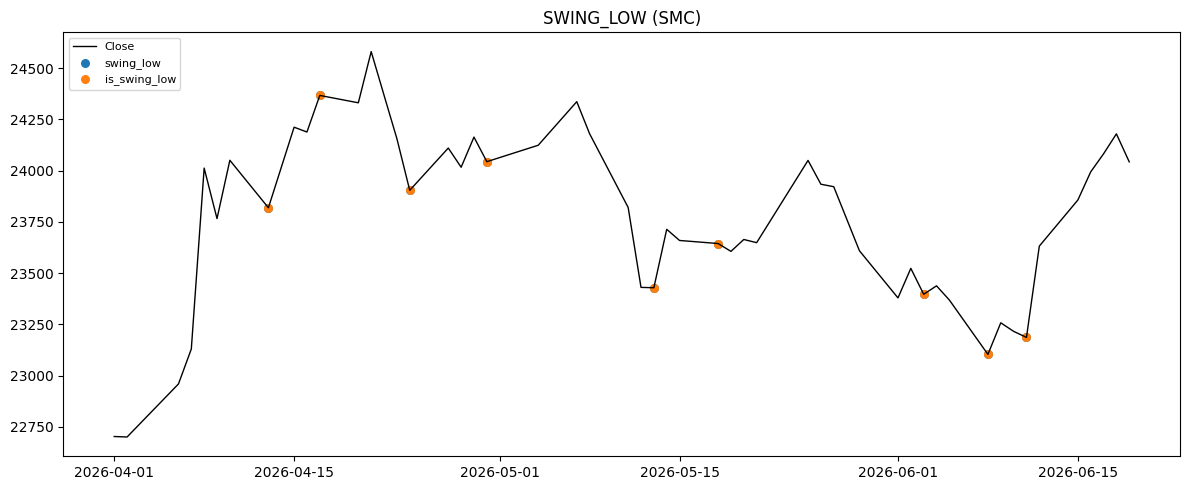

IndicatorResult(name='SWING_LOW', group='Market Structure', params_used={'length': 2}, outputs={'swing_low': array([     nan,      nan,      nan,      nan,      nan,      nan,
            nan, 23555.6 ,      nan,      nan, 24096.05,      nan,
            nan,      nan,      nan, 23813.65,      nan,      nan,
            nan, 23796.85,      nan,      nan,      nan,      nan,
            nan, 23262.55,      nan,      nan, 23317.1 ,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan, 23151.5 ,      nan,      nan,
       23070.15,      nan,      nan, 23072.05,      nan,      nan,
            nan,      nan,      nan,      nan]), 'is_swing_low': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0.])}, warmup_bars=7, status='success', message='OK', vali

In [6]:
test_smc_indicator("SWING_LOW")


### SWING_POINTS
Outputs: `['swing_high', 'is_swing_high', 'swing_low', 'is_swing_low']` · Defaults: `{'length': 2}`


SWING_POINTS  |  Market Structure  (SMC)
Status: success  |  Warmup: 52
Outputs: ['swing_high', 'is_swing_high', 'swing_low', 'is_swing_low']  |  Params: {'length': 2}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: SMC event/signal columns present.
  [OK] not_all_nan: SMC outputs valid (sparse events expected).


,close,swing_high,is_swing_high,swing_low,is_swing_low
date,,,,,
2026-05-22 00:00:00+00:00,23748.85,NaN,0.0,NaN,0.0
2026-05-25 00:00:00+00:00,24049.90,NaN,0.0,NaN,0.0
2026-05-26 00:00:00+00:00,23933.75,24089.80,1.0,NaN,0.0
2026-05-27 00:00:00+00:00,23921.60,NaN,0.0,NaN,0.0
2026-05-29 00:00:00+00:00,23609.30,NaN,0.0,NaN,0.0
2026-06-01 00:00:00+00:00,23379.20,NaN,0.0,NaN,0.0
2026-06-02 00:00:00+00:00,23523.30,NaN,0.0,NaN,0.0
2026-06-03 00:00:00+00:00,23396.95,NaN,0.0,23151.50,1.0
2026-06-04 00:00:00+00:00,23438.00,NaN,0.0,NaN,0.0


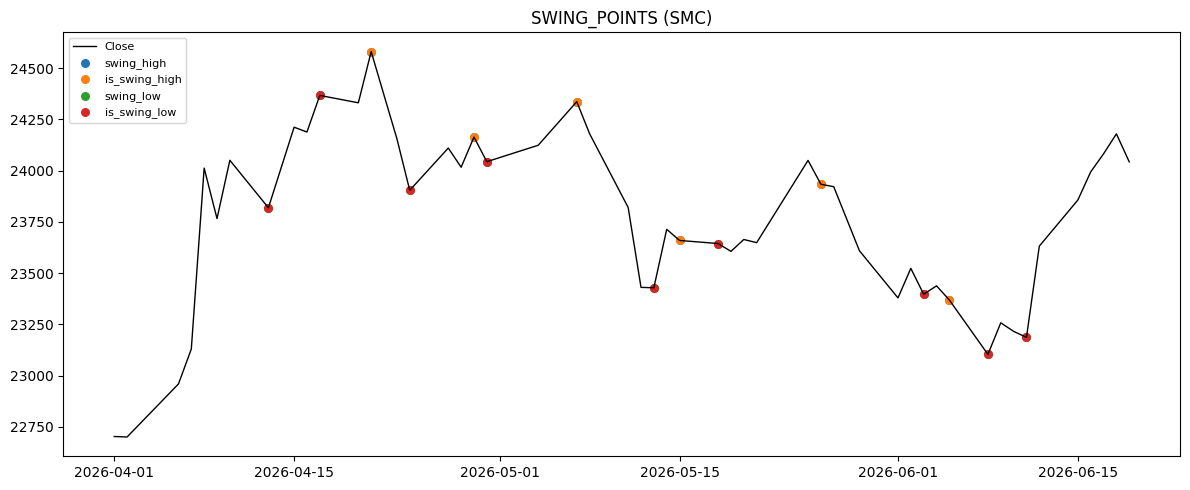

IndicatorResult(name='SWING_POINTS', group='Market Structure', params_used={'length': 2}, outputs={'swing_high': array([     nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
       24601.7 ,      nan,      nan,      nan,      nan,      nan,
       24334.7 ,      nan,      nan, 24482.1 ,      nan,      nan,
            nan,      nan,      nan, 23839.3 ,      nan,      nan,
            nan,      nan,      nan,      nan, 24089.8 ,      nan,
            nan,      nan,      nan,      nan,      nan, 23516.35,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan]), 'is_swing_high': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.]), 'swing_low': array([     nan,      nan,      na

In [7]:
test_smc_indicator("SWING_POINTS")


### MARKET_STRUCTURE
Outputs: `['structure_label', 'trend_bias']` · Defaults: `{'length': 2}`


MARKET_STRUCTURE  |  Market Structure  (SMC)
Status: success  |  Warmup: 0
Outputs: ['structure_label', 'trend_bias']  |  Params: {'length': 2}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,trend_bias
date,,
2026-05-22 00:00:00+00:00,23748.85,1.0
2026-05-25 00:00:00+00:00,24049.90,1.0
2026-05-26 00:00:00+00:00,23933.75,1.0
2026-05-27 00:00:00+00:00,23921.60,1.0
2026-05-29 00:00:00+00:00,23609.30,1.0
2026-06-01 00:00:00+00:00,23379.20,1.0
2026-06-02 00:00:00+00:00,23523.30,1.0
2026-06-03 00:00:00+00:00,23396.95,-1.0
2026-06-04 00:00:00+00:00,23438.00,-1.0


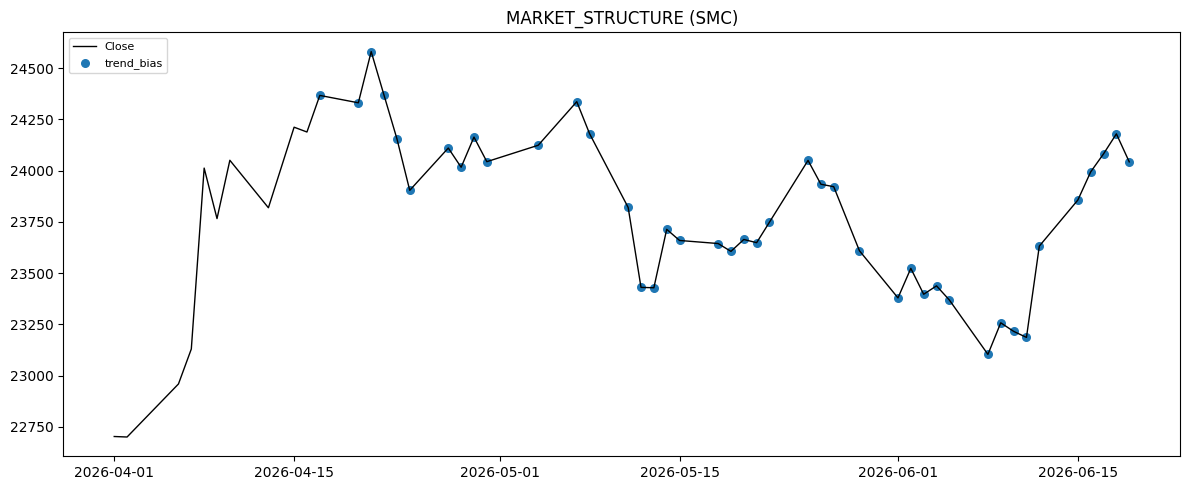

IndicatorResult(name='MARKET_STRUCTURE', group='Market Structure', params_used={'length': 2}, outputs={'structure_label': array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 'HL', nan, nan,
       nan, nan, 'LL', nan, nan, 'LH', 'LL', nan, 'HH', nan, nan, nan,
       'LL', nan, 'LH', 'HL', nan, nan, nan, nan, nan, 'HH', nan, nan,
       nan, nan, 'LL', nan, 'LH', 'LL', nan, nan, 'HL', nan, nan, nan,
       nan, nan, nan], dtype=object), 'trend_bias': array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,
        1.,  1., -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,  1., -1.,
       -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
       -1., -1., -1., -1., -1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite va

In [8]:
test_smc_indicator("MARKET_STRUCTURE")


### BOS
Outputs: `['bos_bull', 'bos_bear']` · Defaults: `{'length': 2}`


BOS  |  Market Structure  (SMC)
Status: success  |  Warmup: 0
Outputs: ['bos_bull', 'bos_bear']  |  Params: {'length': 2}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,bos_bull,bos_bear
date,,,
2026-05-22 00:00:00+00:00,23748.85,0.0,0.0
2026-05-25 00:00:00+00:00,24049.90,1.0,0.0
2026-05-26 00:00:00+00:00,23933.75,1.0,0.0
2026-05-27 00:00:00+00:00,23921.60,0.0,0.0
2026-05-29 00:00:00+00:00,23609.30,0.0,0.0
2026-06-01 00:00:00+00:00,23379.20,0.0,0.0
2026-06-02 00:00:00+00:00,23523.30,0.0,0.0
2026-06-03 00:00:00+00:00,23396.95,0.0,0.0
2026-06-04 00:00:00+00:00,23438.00,0.0,0.0


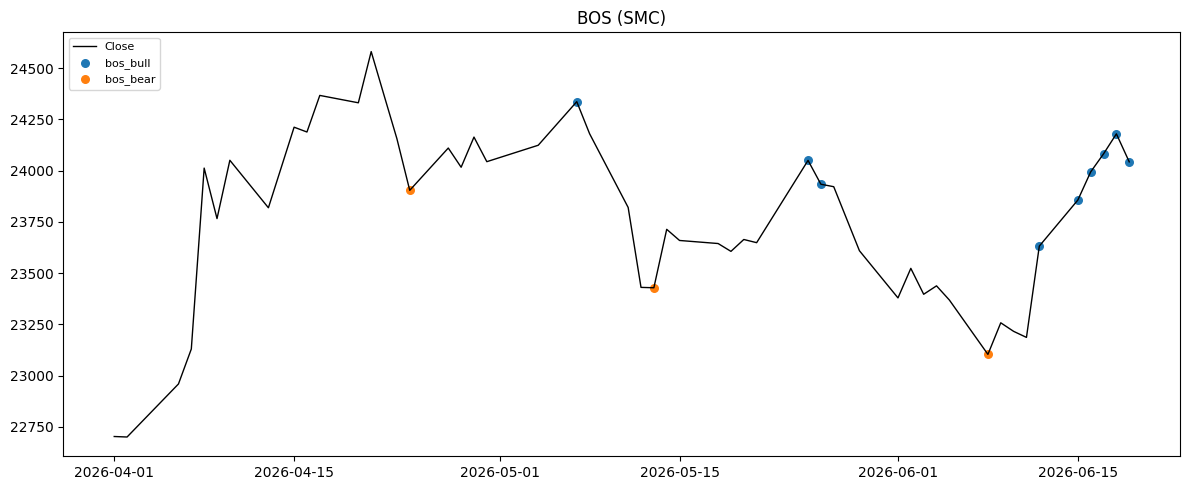

IndicatorResult(name='BOS', group='Market Structure', params_used={'length': 2}, outputs={'bos_bull': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       1.]), 'bos_bear': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [9]:
test_smc_indicator("BOS")


### CHOCH
Outputs: `['choch_bull', 'choch_bear']` · Defaults: `{'length': 2}`


CHOCH  |  Market Structure  (SMC)
Status: success  |  Warmup: 0
Outputs: ['choch_bull', 'choch_bear']  |  Params: {'length': 2}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,choch_bull,choch_bear
date,,,
2026-05-22 00:00:00+00:00,23748.85,0.0,0.0
2026-05-25 00:00:00+00:00,24049.90,0.0,0.0
2026-05-26 00:00:00+00:00,23933.75,0.0,0.0
2026-05-27 00:00:00+00:00,23921.60,0.0,0.0
2026-05-29 00:00:00+00:00,23609.30,0.0,0.0
2026-06-01 00:00:00+00:00,23379.20,0.0,0.0
2026-06-02 00:00:00+00:00,23523.30,0.0,0.0
2026-06-03 00:00:00+00:00,23396.95,0.0,0.0
2026-06-04 00:00:00+00:00,23438.00,0.0,0.0


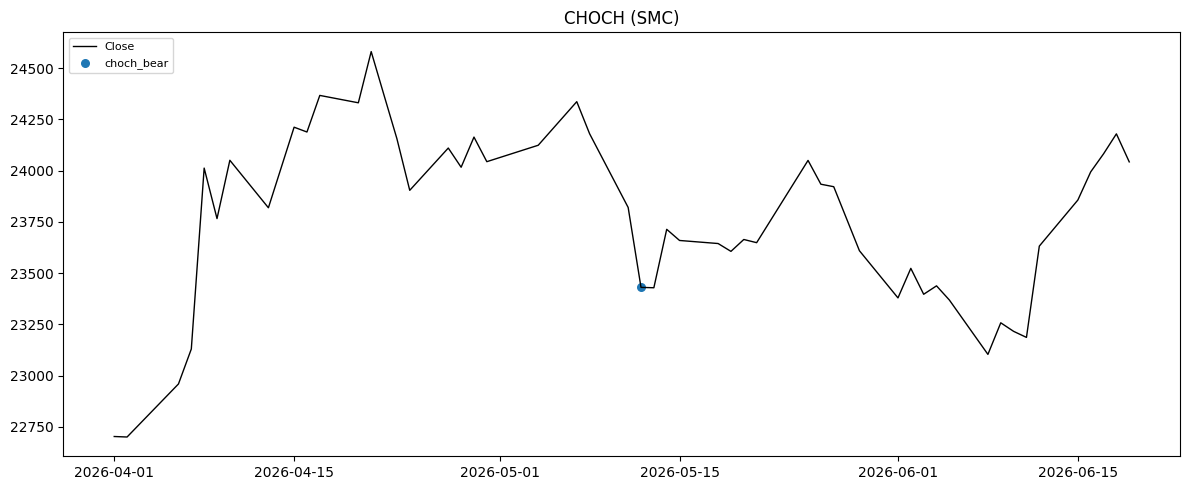

IndicatorResult(name='CHOCH', group='Market Structure', params_used={'length': 2}, outputs={'choch_bull': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.]), 'choch_bear': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [10]:
test_smc_indicator("CHOCH")


### INTERNAL_SWINGS
Outputs: `['swing_high', 'is_swing_high', 'swing_low', 'is_swing_low']` · Defaults: `{'length': 1}`


INTERNAL_SWINGS  |  Market Structure  (SMC)
Status: success  |  Warmup: 52
Outputs: ['swing_high', 'is_swing_high', 'swing_low', 'is_swing_low']  |  Params: {'length': 2}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: SMC event/signal columns present.
  [OK] not_all_nan: SMC outputs valid (sparse events expected).


,close,swing_high,is_swing_high,swing_low,is_swing_low
date,,,,,
2026-05-22 00:00:00+00:00,23748.85,NaN,0.0,NaN,0.0
2026-05-25 00:00:00+00:00,24049.90,NaN,0.0,NaN,0.0
2026-05-26 00:00:00+00:00,23933.75,24089.80,1.0,NaN,0.0
2026-05-27 00:00:00+00:00,23921.60,NaN,0.0,NaN,0.0
2026-05-29 00:00:00+00:00,23609.30,NaN,0.0,NaN,0.0
2026-06-01 00:00:00+00:00,23379.20,NaN,0.0,NaN,0.0
2026-06-02 00:00:00+00:00,23523.30,NaN,0.0,NaN,0.0
2026-06-03 00:00:00+00:00,23396.95,NaN,0.0,23151.50,1.0
2026-06-04 00:00:00+00:00,23438.00,NaN,0.0,NaN,0.0


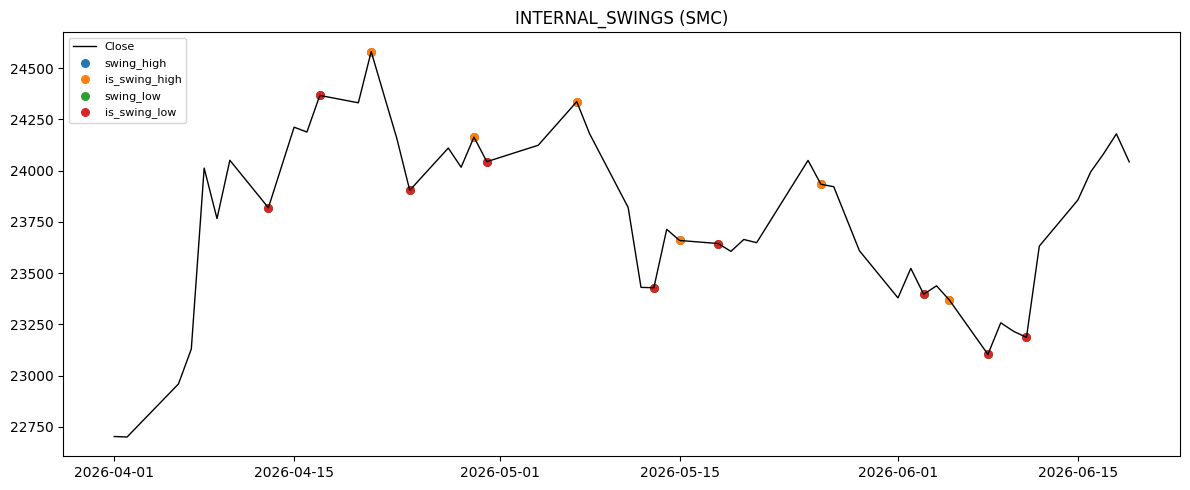

IndicatorResult(name='INTERNAL_SWINGS', group='Market Structure', params_used={'length': 2}, outputs={'swing_high': array([     nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
       24601.7 ,      nan,      nan,      nan,      nan,      nan,
       24334.7 ,      nan,      nan, 24482.1 ,      nan,      nan,
            nan,      nan,      nan, 23839.3 ,      nan,      nan,
            nan,      nan,      nan,      nan, 24089.8 ,      nan,
            nan,      nan,      nan,      nan,      nan, 23516.35,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan]), 'is_swing_high': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.]), 'swing_low': array([     nan,      nan,     

In [11]:
test_smc_indicator("INTERNAL_SWINGS")


<a id="fair-value-gaps"></a>
## Fair Value Gaps (3)


### FVG
Outputs: `['fvg_bull', 'fvg_bear', 'fvg_bull_top', 'fvg_bull_bottom', 'fvg_bear_top', 'fvg_bear_bottom']` · Defaults: `{}`


FVG  |  Fair Value Gaps  (SMC)
Status: success  |  Warmup: 52
Outputs: ['fvg_bull', 'fvg_bear', 'fvg_bull_top', 'fvg_bull_bottom', 'fvg_bear_top', 'fvg_bear_bottom']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: SMC event/signal columns present.
  [OK] not_all_nan: SMC outputs valid (sparse events expected).


,close,fvg_bull,fvg_bear,fvg_bull_top,fvg_bull_bottom,fvg_bear_top,fvg_bear_bottom
date,,,,,,,
2026-05-22 00:00:00+00:00,23748.85,0.0,0.0,NaN,NaN,NaN,NaN
2026-05-25 00:00:00+00:00,24049.90,1.0,0.0,23922.85,23859.90,NaN,NaN
2026-05-26 00:00:00+00:00,23933.75,1.0,0.0,23885.45,23835.65,NaN,NaN
2026-05-27 00:00:00+00:00,23921.60,0.0,0.0,NaN,NaN,NaN,NaN
2026-05-29 00:00:00+00:00,23609.30,0.0,0.0,NaN,NaN,NaN,NaN
2026-06-01 00:00:00+00:00,23379.20,0.0,1.0,NaN,NaN,23858.25,23733.7
2026-06-02 00:00:00+00:00,23523.30,0.0,0.0,NaN,NaN,NaN,NaN
2026-06-03 00:00:00+00:00,23396.95,0.0,0.0,NaN,NaN,NaN,NaN
2026-06-04 00:00:00+00:00,23438.00,0.0,0.0,NaN,NaN,NaN,NaN


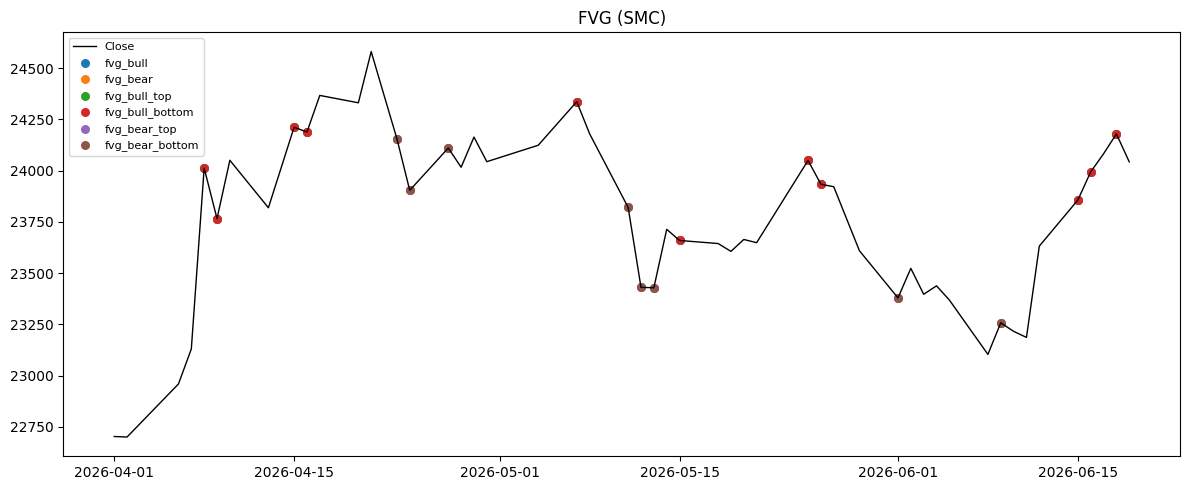

IndicatorResult(name='FVG', group='Fair Value Gaps', params_used={}, outputs={'fvg_bull': array([0., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
       0.]), 'fvg_bear': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
       0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0.]), 'fvg_bull_top': array([     nan,      nan,      nan,      nan, 23828.5 , 23682.8 ,
            nan,      nan, 24145.8 , 24102.8 ,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan, 24284.  ,      nan,      nan,
            nan,      nan,      nan, 23610.3 ,      nan,      nan,
            nan,      nan,      nan, 23922.85, 23885.45,      nan,
    

In [12]:
test_smc_indicator("FVG")


### FVG_BULL
Outputs: `['fvg_bull', 'fvg_bull_top', 'fvg_bull_bottom']` · Defaults: `{}`


FVG_BULL  |  Fair Value Gaps  (SMC)
Status: success  |  Warmup: 4
Outputs: ['fvg_bull', 'fvg_bull_top', 'fvg_bull_bottom']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,fvg_bull,fvg_bull_top,fvg_bull_bottom
date,,,,
2026-05-22 00:00:00+00:00,23748.85,0.0,NaN,NaN
2026-05-25 00:00:00+00:00,24049.90,1.0,23922.85,23859.90
2026-05-26 00:00:00+00:00,23933.75,1.0,23885.45,23835.65
2026-05-27 00:00:00+00:00,23921.60,0.0,NaN,NaN
2026-05-29 00:00:00+00:00,23609.30,0.0,NaN,NaN
2026-06-01 00:00:00+00:00,23379.20,0.0,NaN,NaN
2026-06-02 00:00:00+00:00,23523.30,0.0,NaN,NaN
2026-06-03 00:00:00+00:00,23396.95,0.0,NaN,NaN
2026-06-04 00:00:00+00:00,23438.00,0.0,NaN,NaN


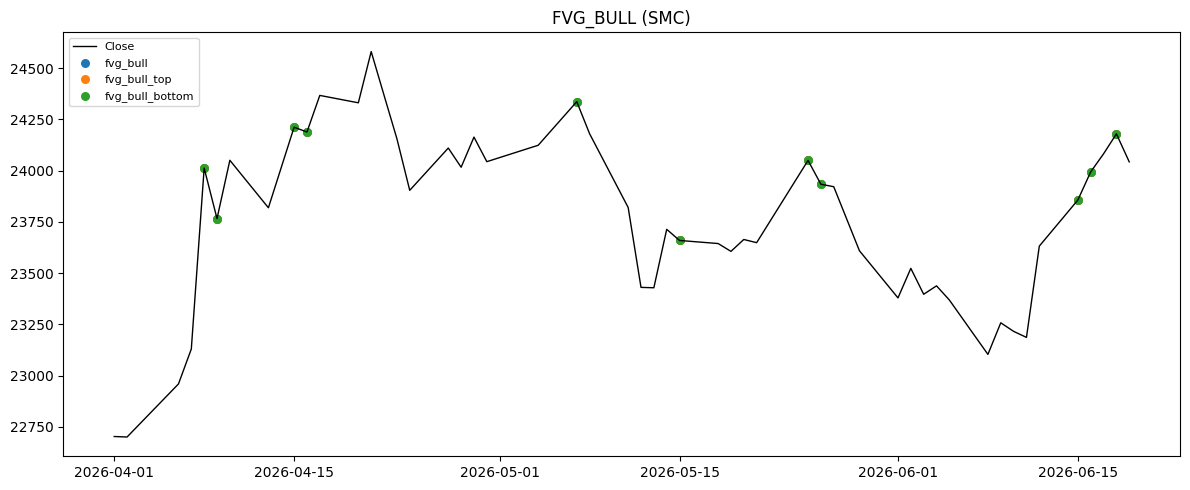

IndicatorResult(name='FVG_BULL', group='Fair Value Gaps', params_used={}, outputs={'fvg_bull': array([0., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
       0.]), 'fvg_bull_top': array([     nan,      nan,      nan,      nan, 23828.5 , 23682.8 ,
            nan,      nan, 24145.8 , 24102.8 ,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan, 24284.  ,      nan,      nan,
            nan,      nan,      nan, 23610.3 ,      nan,      nan,
            nan,      nan,      nan, 23922.85, 23885.45,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan, 23817.8 ,
       23888.2 ,      nan, 24036.95,      nan]), 'fvg_bull_bottom': array([     nan,      nan,      nan,      nan, 

In [13]:
test_smc_indicator("FVG_BULL")


### FVG_BEAR
Outputs: `['fvg_bear', 'fvg_bear_top', 'fvg_bear_bottom']` · Defaults: `{}`


FVG_BEAR  |  Fair Value Gaps  (SMC)
Status: success  |  Warmup: 14
Outputs: ['fvg_bear', 'fvg_bear_top', 'fvg_bear_bottom']  |  Params: {}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,fvg_bear,fvg_bear_top,fvg_bear_bottom
date,,,,
2026-05-22 00:00:00+00:00,23748.85,0.0,NaN,NaN
2026-05-25 00:00:00+00:00,24049.90,0.0,NaN,NaN
2026-05-26 00:00:00+00:00,23933.75,0.0,NaN,NaN
2026-05-27 00:00:00+00:00,23921.60,0.0,NaN,NaN
2026-05-29 00:00:00+00:00,23609.30,0.0,NaN,NaN
2026-06-01 00:00:00+00:00,23379.20,1.0,23858.25,23733.7
2026-06-02 00:00:00+00:00,23523.30,0.0,NaN,NaN
2026-06-03 00:00:00+00:00,23396.95,0.0,NaN,NaN
2026-06-04 00:00:00+00:00,23438.00,0.0,NaN,NaN


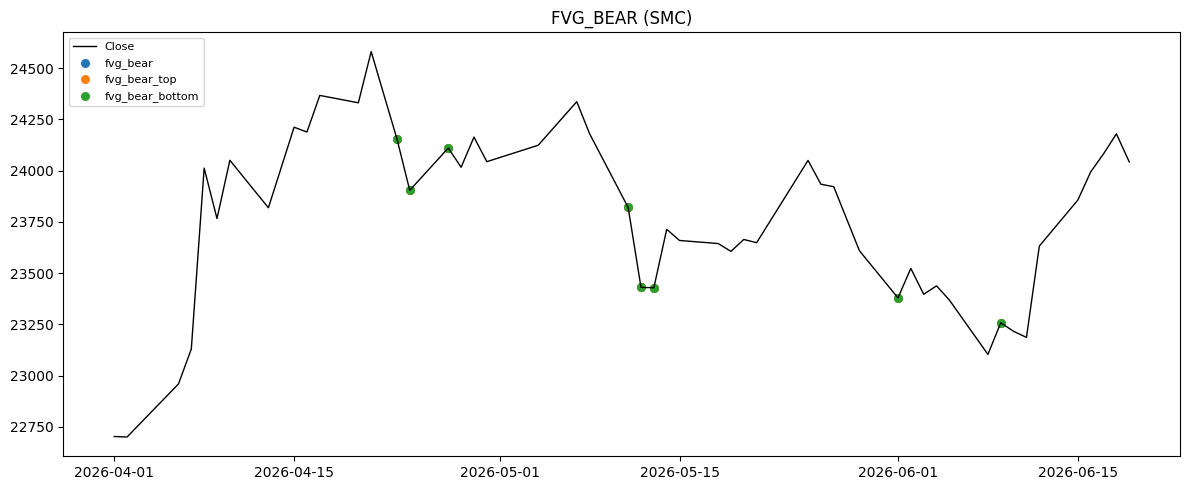

IndicatorResult(name='FVG_BEAR', group='Fair Value Gaps', params_used={}, outputs={'fvg_bear': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
       0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0.]), 'fvg_bear_top': array([     nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan, 24354.9 , 24352.9 , 24134.8 ,      nan,
            nan,      nan,      nan,      nan,      nan, 24284.  ,
       24126.65, 23799.1 ,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan, 23858.25,      nan,      nan,      nan,      nan,
            nan, 23282.65,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan]), 'fvg_bear_bottom': array([     nan,      nan,      nan,      nan, 

In [14]:
test_smc_indicator("FVG_BEAR")


<a id="order-blocks"></a>
## Order Blocks (3)


### ORDER_BLOCKS
Outputs: `['ob_bull', 'ob_bull_low', 'ob_bull_high', 'ob_bear', 'ob_bear_low', 'ob_bear_high']` · Defaults: `{'length': 2, 'impulse_pct': 0.003}`


ORDER_BLOCKS  |  Order Blocks  (SMC)
Status: success  |  Warmup: 52
Outputs: ['ob_bull', 'ob_bull_low', 'ob_bull_high', 'ob_bear', 'ob_bear_low', 'ob_bear_high']  |  Params: {'length': 2, 'impulse_pct': 0.003}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: SMC event/signal columns present.
  [OK] not_all_nan: SMC outputs valid (sparse events expected).


,close,ob_bull,ob_bull_low,ob_bull_high,ob_bear,ob_bear_low,ob_bear_high
date,,,,,,,
2026-05-22 00:00:00+00:00,23748.85,0.0,NaN,NaN,0.0,NaN,NaN
2026-05-25 00:00:00+00:00,24049.90,1.0,23596.6,23859.90,0.0,NaN,NaN
2026-05-26 00:00:00+00:00,23933.75,0.0,NaN,NaN,0.0,NaN,NaN
2026-05-27 00:00:00+00:00,23921.60,0.0,NaN,NaN,0.0,NaN,NaN
2026-05-29 00:00:00+00:00,23609.30,0.0,NaN,NaN,0.0,NaN,NaN
2026-06-01 00:00:00+00:00,23379.20,0.0,NaN,NaN,0.0,NaN,NaN
2026-06-02 00:00:00+00:00,23523.30,0.0,NaN,NaN,0.0,NaN,NaN
2026-06-03 00:00:00+00:00,23396.95,0.0,NaN,NaN,0.0,NaN,NaN
2026-06-04 00:00:00+00:00,23438.00,0.0,NaN,NaN,0.0,NaN,NaN


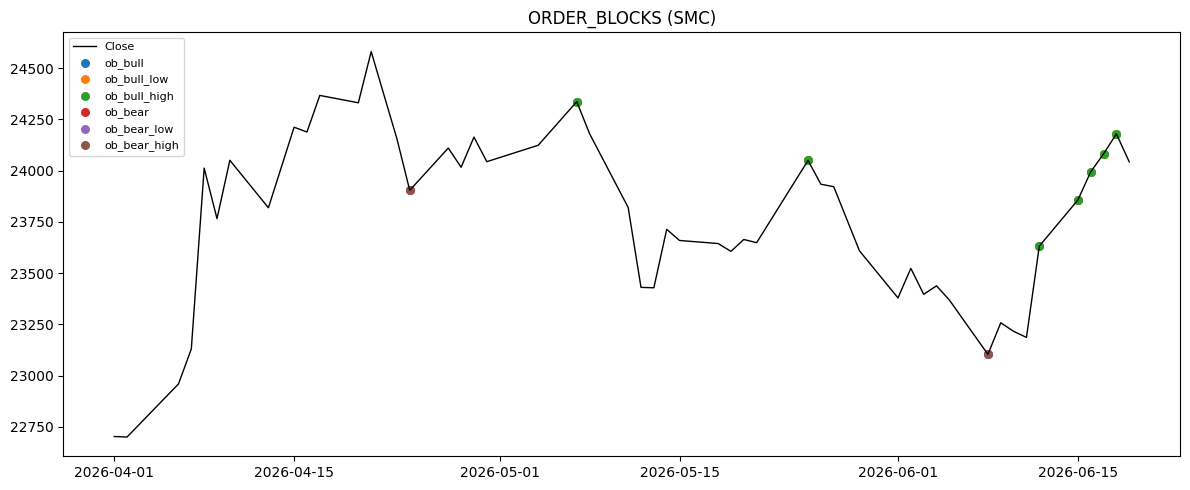

IndicatorResult(name='ORDER_BLOCKS', group='Order Blocks', params_used={'length': 2, 'impulse_pct': 0.003}, outputs={'ob_bull': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       0.]), 'ob_bull_low': array([     nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan, 23957.05,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan, 23596.6 ,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan, 23184.6 , 23184.6 ,
       23817.8 , 23817.8 , 23817.8 ,      nan]), 'ob_bull_high': array([     nan,  

In [15]:
test_smc_indicator("ORDER_BLOCKS")


### ORDER_BLOCK_BULL
Outputs: `['ob_bull', 'ob_bull_low', 'ob_bull_high']` · Defaults: `{'length': 2, 'impulse_pct': 0.003}`


ORDER_BLOCK_BULL  |  Order Blocks  (SMC)
Status: success  |  Warmup: 21
Outputs: ['ob_bull', 'ob_bull_low', 'ob_bull_high']  |  Params: {'length': 2, 'impulse_pct': 0.003}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,ob_bull,ob_bull_low,ob_bull_high
date,,,,
2026-05-22 00:00:00+00:00,23748.85,0.0,NaN,NaN
2026-05-25 00:00:00+00:00,24049.90,1.0,23596.6,23859.90
2026-05-26 00:00:00+00:00,23933.75,0.0,NaN,NaN
2026-05-27 00:00:00+00:00,23921.60,0.0,NaN,NaN
2026-05-29 00:00:00+00:00,23609.30,0.0,NaN,NaN
2026-06-01 00:00:00+00:00,23379.20,0.0,NaN,NaN
2026-06-02 00:00:00+00:00,23523.30,0.0,NaN,NaN
2026-06-03 00:00:00+00:00,23396.95,0.0,NaN,NaN
2026-06-04 00:00:00+00:00,23438.00,0.0,NaN,NaN


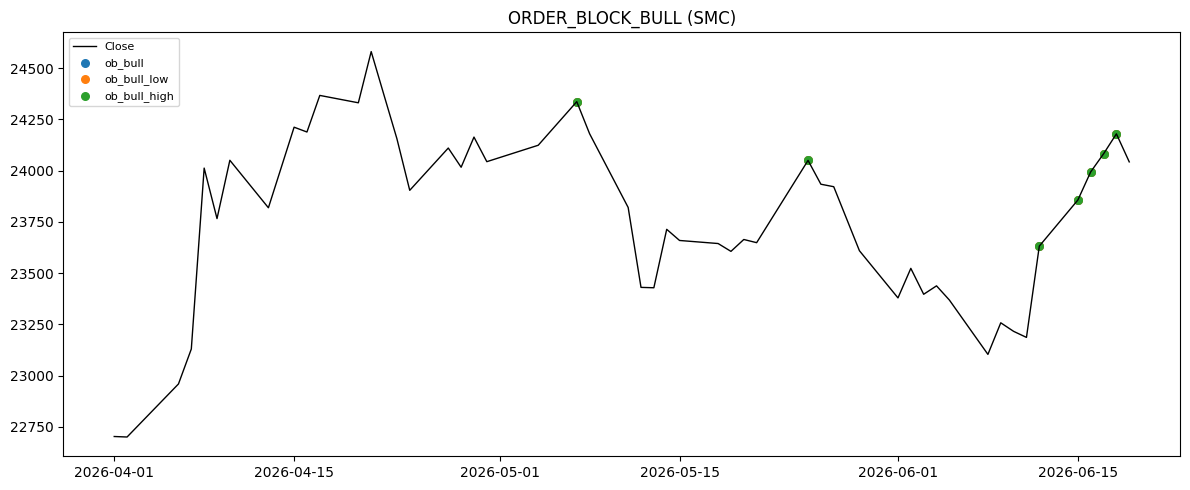

IndicatorResult(name='ORDER_BLOCK_BULL', group='Order Blocks', params_used={'length': 2, 'impulse_pct': 0.003}, outputs={'ob_bull': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       0.]), 'ob_bull_low': array([     nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan, 23957.05,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan, 23596.6 ,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan, 23184.6 , 23184.6 ,
       23817.8 , 23817.8 , 23817.8 ,      nan]), 'ob_bull_high': array([     na

In [16]:
test_smc_indicator("ORDER_BLOCK_BULL")


### ORDER_BLOCK_BEAR
Outputs: `['ob_bear', 'ob_bear_low', 'ob_bear_high']` · Defaults: `{'length': 2, 'impulse_pct': 0.003}`


ORDER_BLOCK_BEAR  |  Order Blocks  (SMC)
Status: success  |  Warmup: 15
Outputs: ['ob_bear', 'ob_bear_low', 'ob_bear_high']  |  Params: {'length': 2, 'impulse_pct': 0.003}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,ob_bear,ob_bear_low,ob_bear_high
date,,,,
2026-05-22 00:00:00+00:00,23748.85,0.0,NaN,NaN
2026-05-25 00:00:00+00:00,24049.90,0.0,NaN,NaN
2026-05-26 00:00:00+00:00,23933.75,0.0,NaN,NaN
2026-05-27 00:00:00+00:00,23921.60,0.0,NaN,NaN
2026-05-29 00:00:00+00:00,23609.30,0.0,NaN,NaN
2026-06-01 00:00:00+00:00,23379.20,0.0,NaN,NaN
2026-06-02 00:00:00+00:00,23523.30,0.0,NaN,NaN
2026-06-03 00:00:00+00:00,23396.95,0.0,NaN,NaN
2026-06-04 00:00:00+00:00,23438.00,0.0,NaN,NaN


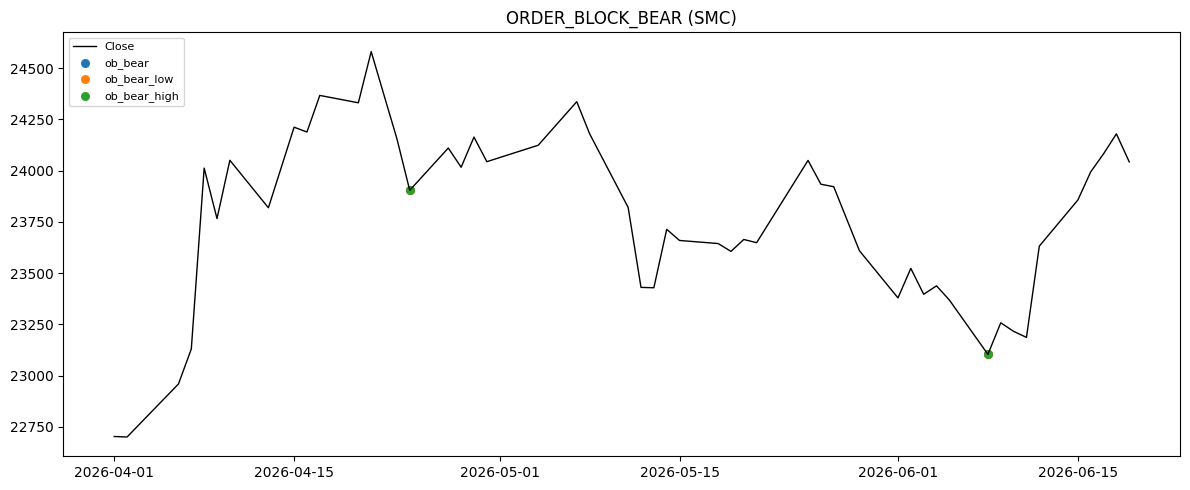

IndicatorResult(name='ORDER_BLOCK_BEAR', group='Order Blocks', params_used={'length': 2, 'impulse_pct': 0.003}, outputs={'ob_bear': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.]), 'ob_bear_low': array([    nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan, 24354.9,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan,     nan,     nan,     nan,     nan,
       23247.3,     nan,     nan,     nan,     nan,     nan,     nan,
           nan,     nan,     nan]), 'ob_bear_high': array([    nan,     nan,     nan,     nan,     nan,     nan,     nan,
   

In [17]:
test_smc_indicator("ORDER_BLOCK_BEAR")


<a id="liquidity"></a>
## Liquidity (2)


### LIQUIDITY_SWEEPS
Outputs: `['liquidity_sweep_high', 'liquidity_sweep_low']` · Defaults: `{'length': 2}`


LIQUIDITY_SWEEPS  |  Liquidity  (SMC)
Status: success  |  Warmup: 0
Outputs: ['liquidity_sweep_high', 'liquidity_sweep_low']  |  Params: {'length': 2}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,liquidity_sweep_high,liquidity_sweep_low
date,,,
2026-05-22 00:00:00+00:00,23748.85,0.0,0.0
2026-05-25 00:00:00+00:00,24049.90,0.0,0.0
2026-05-26 00:00:00+00:00,23933.75,0.0,0.0
2026-05-27 00:00:00+00:00,23921.60,0.0,0.0
2026-05-29 00:00:00+00:00,23609.30,0.0,0.0
2026-06-01 00:00:00+00:00,23379.20,0.0,0.0
2026-06-02 00:00:00+00:00,23523.30,0.0,0.0
2026-06-03 00:00:00+00:00,23396.95,0.0,0.0
2026-06-04 00:00:00+00:00,23438.00,0.0,0.0


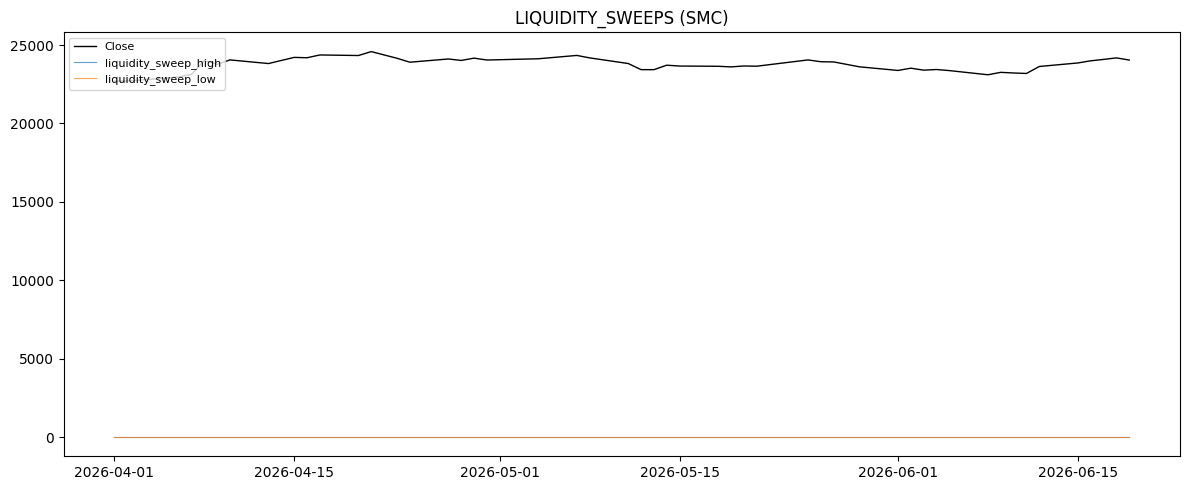

IndicatorResult(name='LIQUIDITY_SWEEPS', group='Liquidity', params_used={'length': 2}, outputs={'liquidity_sweep_high': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.]), 'liquidity_sweep_low': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [18]:
test_smc_indicator("LIQUIDITY_SWEEPS")


### EQUAL_HIGHS_LOWS
Outputs: `['equal_highs', 'equal_lows']` · Defaults: `{'length': 2, 'tolerance_pct': 0.0005}`


EQUAL_HIGHS_LOWS  |  Liquidity  (SMC)
Status: success  |  Warmup: 0
Outputs: ['equal_highs', 'equal_lows']  |  Params: {'length': 2, 'tolerance_pct': 0.0005}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,equal_highs,equal_lows
date,,,
2026-05-22 00:00:00+00:00,23748.85,0.0,0.0
2026-05-25 00:00:00+00:00,24049.90,0.0,0.0
2026-05-26 00:00:00+00:00,23933.75,0.0,0.0
2026-05-27 00:00:00+00:00,23921.60,0.0,0.0
2026-05-29 00:00:00+00:00,23609.30,0.0,0.0
2026-06-01 00:00:00+00:00,23379.20,0.0,0.0
2026-06-02 00:00:00+00:00,23523.30,0.0,0.0
2026-06-03 00:00:00+00:00,23396.95,0.0,0.0
2026-06-04 00:00:00+00:00,23438.00,0.0,0.0


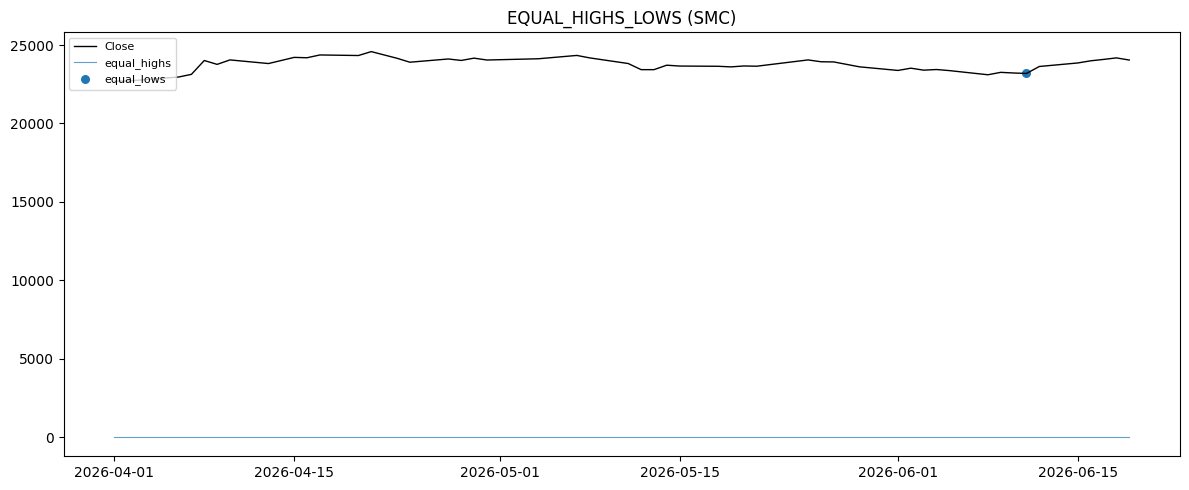

IndicatorResult(name='EQUAL_HIGHS_LOWS', group='Liquidity', params_used={'length': 2, 'tolerance_pct': 0.0005}, outputs={'equal_highs': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.]), 'equal_lows': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
       0.])}, warmup_bars=0, status='success', message='OK', validation=ValidationResult(passed=True, checks=[Check(name='length', passed=True, message='All output lengths match input.'), Check(name='post_warmup_data', passed=True, message='At least one finite value after warmup.'), Check(name='not_all_nan', passed=True, message='Outputs contain data after warmup.')]))

In [19]:
test_smc_indicator("EQUAL_HIGHS_LOWS")


<a id="premium--discount"></a>
## Premium / Discount (2)


### PREMIUM_DISCOUNT
Outputs: `['range_pct', 'equilibrium', 'zone']` · Defaults: `{'length': 2}`


PREMIUM_DISCOUNT  |  Premium / Discount  (SMC)
Status: success  |  Warmup: 12
Outputs: ['range_pct', 'equilibrium', 'zone']  |  Params: {'length': 2}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,range_pct,equilibrium
date,,,
2026-05-22 00:00:00+00:00,23748.85,82.679050,23578.200
2026-05-25 00:00:00+00:00,24049.90,140.329376,23578.200
2026-05-26 00:00:00+00:00,23933.75,79.804581,23703.450
2026-05-27 00:00:00+00:00,23921.60,78.232173,23703.450
2026-05-29 00:00:00+00:00,23609.30,37.815452,23703.450
2026-06-01 00:00:00+00:00,23379.20,8.036754,23703.450
2026-06-02 00:00:00+00:00,23523.30,26.685648,23703.450
2026-06-03 00:00:00+00:00,23396.95,26.159011,23620.650
2026-06-04 00:00:00+00:00,23438.00,30.533944,23620.650


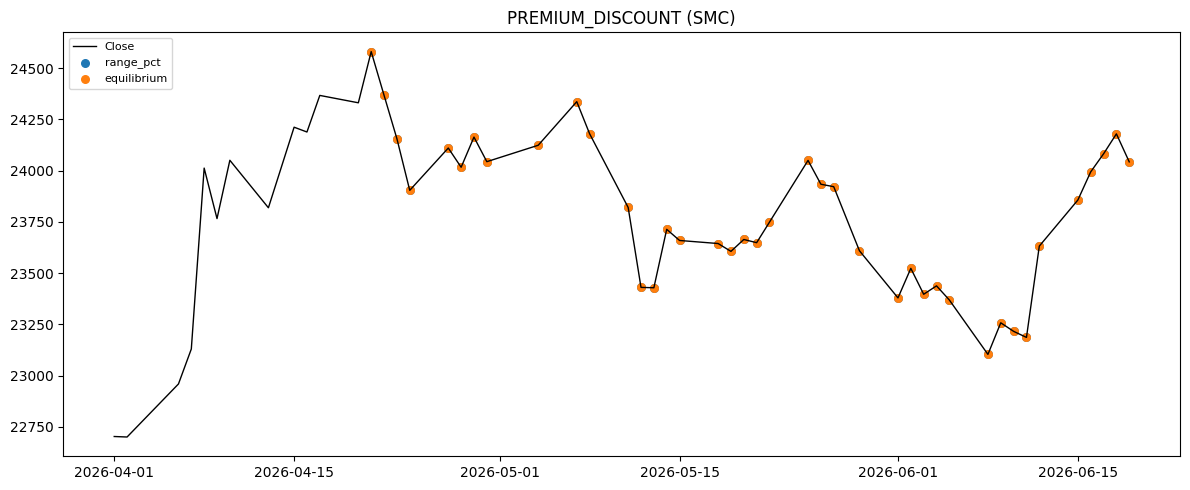

IndicatorResult(name='PREMIUM_DISCOUNT', group='Premium / Discount', params_used={'length': 2}, outputs={'range_pct': array([         nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
                nan,          nan,          nan,          nan,
        95.82715317,  53.71304262,  11.86591516,  11.45866379,
        37.63086099,  25.74075249,  67.16246042,  45.89569583,
        60.78832388,  78.73768698,  55.88471361,   3.42940533,
       -53.45494345,  13.62387766,  36.99725309,  68.79930646,
        62.68671007,  55.36193029,  66.45921103,  63.48142474,
        82.67905017, 140.32937572,  79.80458134,  78.2321729 ,
        37.81545231,   8.03675424,  26.68564773,  26.15901098,
        30.53394437,  59.57242702,   7.51904975,  42.04392649,
        32.70954729,  25.77087553, 125.97344137, 176.56988521,
       207.49493585, 227.30137295, 249.23475129, 218.46725186]), 'equilibrium': array([      nan,       nan,       nan,       

In [20]:
test_smc_indicator("PREMIUM_DISCOUNT")


### DEALING_RANGE
Outputs: `['range_high', 'range_low', 'equilibrium']` · Defaults: `{'length': 2}`


DEALING_RANGE  |  Premium / Discount  (SMC)
Status: success  |  Warmup: 12
Outputs: ['range_high', 'range_low', 'equilibrium']  |  Params: {'length': 2}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,range_high,range_low,equilibrium
date,,,,
2026-05-22 00:00:00+00:00,23748.85,23839.30,23317.10,23578.200
2026-05-25 00:00:00+00:00,24049.90,23839.30,23317.10,23578.200
2026-05-26 00:00:00+00:00,23933.75,24089.80,23317.10,23703.450
2026-05-27 00:00:00+00:00,23921.60,24089.80,23317.10,23703.450
2026-05-29 00:00:00+00:00,23609.30,24089.80,23317.10,23703.450
2026-06-01 00:00:00+00:00,23379.20,24089.80,23317.10,23703.450
2026-06-02 00:00:00+00:00,23523.30,24089.80,23317.10,23703.450
2026-06-03 00:00:00+00:00,23396.95,24089.80,23151.50,23620.650
2026-06-04 00:00:00+00:00,23438.00,24089.80,23151.50,23620.650


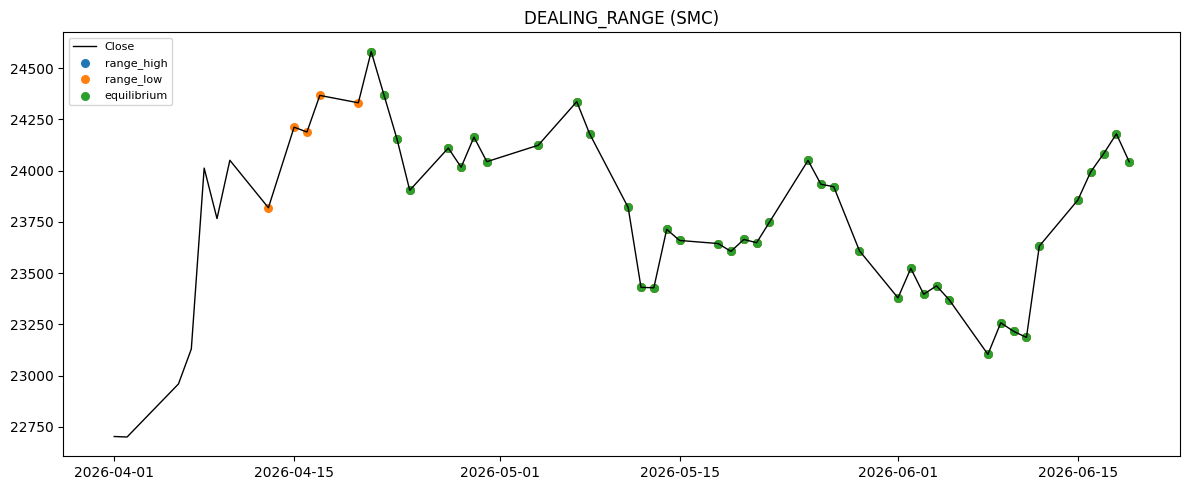

IndicatorResult(name='DEALING_RANGE', group='Premium / Discount', params_used={'length': 2}, outputs={'range_high': array([     nan,      nan,      nan,      nan,      nan,      nan,
            nan,      nan,      nan,      nan,      nan,      nan,
       24601.7 , 24601.7 , 24601.7 , 24601.7 , 24601.7 , 24601.7 ,
       24334.7 , 24334.7 , 24334.7 , 24482.1 , 24482.1 , 24482.1 ,
       24482.1 , 24482.1 , 24482.1 , 23839.3 , 23839.3 , 23839.3 ,
       23839.3 , 23839.3 , 23839.3 , 23839.3 , 24089.8 , 24089.8 ,
       24089.8 , 24089.8 , 24089.8 , 24089.8 , 24089.8 , 23516.35,
       23516.35, 23516.35, 23516.35, 23516.35, 23516.35, 23516.35,
       23516.35, 23516.35, 23516.35, 23516.35]), 'range_low': array([     nan,      nan,      nan,      nan,      nan,      nan,
            nan, 23555.6 , 23555.6 , 23555.6 , 24096.05, 24096.05,
       24096.05, 24096.05, 24096.05, 23813.65, 23813.65, 23813.65,
       23813.65, 23796.85, 23796.85, 23796.85, 23796.85, 23796.85,
       23796.85, 2

In [21]:
test_smc_indicator("DEALING_RANGE")
